# ШАГ 1: Генерация поведенческого датасета и поиск Якорей среды

In [12]:
import pandas as pd
import numpy as np

# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКОГО ДАТАСЕТА "АВТОСАЛОН ЭЛЕКТРОМОБИЛЕЙ"
np.random.seed(42)
n_samples = 1000

data = {
    'Доход_тыс_руб': np.random.normal(150, 80, n_samples),  # Непрерывный признак
    'Возраст': np.random.randint(16, 75, n_samples),         # Непрерывный признак
    'Инфраструктура_EV': np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7]) # Есть ли зарядки рядом
}

df = pd.DataFrame(data)

# Логика скрытых триггеров (целевая переменная Купил/Не купил)
y = []
for idx, row in df.iterrows():
    if row['Возраст'] < 18 or row['Доход_тыс_руб'] <= 30:
        prob = 0.01  # Анти-Якорь (Фильтр отсечки)
    elif row['Доход_тыс_руб'] > 300 and row['Инфраструктура_EV'] == 1:
        prob = 0.95  # Положительный Якорь
    else:
        prob = 0.48  # Зона Блефа (Сомневающиеся)

    y.append(np.random.choice([0, 1], p=[1 - prob, prob]))

df['Купил_электромобиль'] = y
print(f"[+] Базовый датасет успешно сгенерирован! Размерность: {df.shape}")

[+] Базовый датасет успешно сгенерирован! Размерность: (1000, 4)


In [13]:
# 2. АЛГОРИТМ ИДЕНТИФИКАЦИИ ЯКОРЕЙ И АНТИ-ЯКОРЕЙ
def identify_anchors_and_filters(df, continuous_cols, target_col, bluff_threshold=0.15):
    positive_anchors = {}
    anti_anchors = {}
    bluff_zones = {}

    for col in continuous_cols:
        df_temp = df.copy()
        df_temp['bin'] = pd.qcut(df_temp[col], q=5, duplicates='drop', labels=False)
        stats = df_temp.groupby('bin')[target_col].agg(['mean', 'count'])

        for bin_idx, row in stats.iterrows():
            prob = row['mean']
            bin_data = df_temp[df_temp['bin'] == bin_idx][col]
            min_val, max_val = bin_data.min(), bin_data.max()
            interval_str = f"[{min_val:.1f} - {max_val:.1f}] (P={prob:.2f})"

            if prob >= 0.80:
                if col not in positive_anchors: positive_anchors[col] = []
                positive_anchors[col].append(interval_str)
            elif prob <= 0.10:
                if col not in anti_anchors: anti_anchors[col] = []
                anti_anchors[col].append(interval_str)
            elif 0.5 - bluff_threshold < prob < 0.5 + bluff_threshold:
                if col not in bluff_zones: bluff_zones[col] = []
                bluff_zones[col].append(interval_str)

    return positive_anchors, anti_anchors, bluff_zones

pos, anti, bluff = identify_anchors_and_filters(df, ['Доход_тыс_руб', 'Возраст'], 'Купил_электромобиль')
print("[+] Шаг 1 успешно выполнен! Базовые Якоря среды идентифицированы.")

[+] Шаг 1 успешно выполнен! Базовые Якоря среды идентифицированы.


# ШАГ 2: Мульти-популяционное подтягивание (Расчет Локального Среднего Поля)

In [14]:
# 3. АЛГОРИТМ ЭВОЛЮЦИИ СРЕДНЕГО ПОЛЯ ДЛЯ СОМНЕВАЮЩИХСЯ
def calculate_mean_field_pull(df, target_col):
    """
    Реализует поведенческую логику подтягивания сомневающихся за лидерами их групп (Якорями)
    """
    df_mfg = df.copy()

    # Выделяем возрастные популяции (Группы: Молодежь, Зрелые, Старшие)
    df_mfg['Популяция_Возраст'] = pd.cut(df_mfg['Возраст'], bins=[0, 35, 55, 100], labels=['Молодые', 'Зрелые', 'Старшие'])

    # Находим 'Якорей' в каждой популяции (высокий доход)
    df_mfg['Тип_Агента'] = 'Сомневающийся'
    df_mfg.loc[df_mfg['Доход_тыс_руб'] > 300, 'Тип_Агента'] = 'Якорь'
    df_mfg.loc[(df_mfg['Возраст'] < 18) | (df_mfg['Доход_тыс_руб'] <= 30), 'Тип_Агента'] = 'Фильтр_Отсечки'

    # Считаем силу Локального Среднего Поля (долю покупок среди Якорей в каждой возрастной группе)
    local_field_strength = df_mfg[df_mfg['Тип_Агента'] == 'Якорь'].groupby('Популяция_Возраст', observed=False)[target_col].mean().to_dict()

    print("=== СИЛА ЛОКАЛЬНЫХ СРЕДНИХ ПОЛЕЙ (АКТИВНОСТЬ ЯКОРЕЙ) ===")
    for pop, strength in local_field_strength.items():
        print(f"  • Группа '{pop}': интенсивность покупок лидеров = {strength:.2f}")

    # Моделируем 'подтягивание': сомневающиеся корректируют свои шансы на основе силы своего поля
    adjusted_probabilities = []

    for idx, row in df_mfg.iterrows():
        if row['Тип_Агента'] == 'Сомневающийся':
            pop = row['Популяция_Возраст']
            field_influence = local_field_strength.get(pop, 0.5)

            # Поведенческий сдвиг: если лидеры активны (>0.7), шанс покупки сомневающегося растет
            base_prob = 0.48
            mfg_impulse = 0.25 * (field_influence - 0.5)
            final_prob = base_prob + mfg_impulse
        elif row['Тип_Агента'] == 'Якорь':
            final_prob = 0.95
        else:
            final_prob = 0.01

        adjusted_probabilities.append(final_prob)

    df_mfg['MFG_Вероятность'] = adjusted_probabilities
    print("\n[+] Локальные средние поля рассчитаны. Поведенческий импульс успешно внедрен в датасет!")
    return df_mfg

df_final = calculate_mean_field_pull(df, 'Купил_электромобиль')

=== СИЛА ЛОКАЛЬНЫХ СРЕДНИХ ПОЛЕЙ (АКТИВНОСТЬ ЯКОРЕЙ) ===
  • Группа 'Молодые': интенсивность покупок лидеров = 0.90
  • Группа 'Зрелые': интенсивность покупок лидеров = 0.77
  • Группа 'Старшие': интенсивность покупок лидеров = 0.71

[+] Локальные средние поля рассчитаны. Поведенческий импульс успешно внедрен в датасет!


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сетки и времени
T = 1.0          # Временной горизонт
Nt = 200         # УВЕЛИЧЕНО для выполнения критерия CFL и численной стабильности
dt = T / Nt
t_space = np.linspace(0, T, Nt + 1)

Nx = 60          # Число шагов по пространству состояний агента
x_min, x_max = -2.0, 2.0
x_space = np.linspace(x_min, x_max, Nx)
dx = (x_max - x_min) / (Nx - 1)

# Экономические / поведенческие параметры MFG
sigma = 0.3      # Коэффициент диффузии (шум)
nu = 0.5         # Цена управляющего усилия
gamma = 1.5      # Штраф за нахождение в высокой плотности (Mean Field)

print(f"Параметры переинициализированы.\nШаг dx: {dx:.4f}, Шаг dt: {dt:.4f}")
print(f"CFL Диффузии (должен быть < 0.5): {(0.5 * sigma**2 * dt) / (dx**2):.4f}")


Параметры переинициализированы.
Шаг dx: 0.0678, Шаг dt: 0.0050
CFL Диффузии (должен быть < 0.5): 0.0490


In [21]:
def running_cost(x, u, m):
    """
    Текущие издержки агента: квадратичное усилие + штраф за скученность (Mean Field)
    """
    # Агенты хотят минимизировать u^2 и избегать мест с высокой плотностью m
    return 0.5 * nu * (u**2) + gamma * m

def terminal_cost(x, m_T):
    """
    Терминальные издержки в момент времени T
    """
    # Стремление агентов оказаться ближе к центру (0.0) в конце игры
    return 0.5 * (x**2)


In [24]:
class BehavioralMFGSolver:
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma):
        self.Nt, self.Nx = Nt, Nx
        self.dt, self.dx = dt, dx
        self.x_space = x_space
        self.sigma = sigma
        self.nu = nu
        self.gamma = gamma

        # Инициализация распределения плотности m(t, x)
        self.m = np.zeros((Nt + 1, Nx))
        initial_distribution = np.exp(-((x_space + 1.0)**2) / (2 * 0.25**2))
        self.m[0, :] = initial_distribution / np.sum(initial_distribution * dx)

        # Начальное заполнение сетки плотности
        for t in range(1, Nt + 1):
            self.m[t, :] = self.m[0, :]

        self.V = np.zeros((Nt + 1, Nx))
        self.u = np.zeros((Nt, Nx))

    def solve_hjb_backward(self):
        """
        Направление НАЗАД: Решаем уравнение HJB с подстановкой оптимального H
        """
        # Терминальное условие: финальные издержки в момент T
        self.V[-1, :] = 0.5 * (self.x_space**2)

        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)

            # Стабилизация: ограничиваем экстремальный рост градиентов функции ценности
            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            # Оптимальное управление из аналитического минимума
            self.u[t, :] = - (1.0 / self.nu) * dV_dx

            # Подстановка максимизированного Гамильтониана: H = -0.5 * (1/nu) * (dV/dx)^2
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)

            # Шаг назад по времени (схема Беллмана с поглощением)
            # Из-за обратного времени знак у диффузии и Гамильтониана меняется на минус
            self.V[t, :] = self.V[t+1, :] - self.dt * (
                0.5 * (self.sigma**2) * d2V_dx2 + H - self.gamma * self.m[t, :]
            )

            # Фиксация от NaN значений
            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

    def solve_fpk_forward(self):
        """
        Направление ВПЕРЕД: Решаем уравнение Фоккера-Планка (FPK)
        """
        for t in range(self.Nt):
            flux = self.m[t, :] * self.u[t, :]
            dflux_dx = np.gradient(flux, self.dx)

            d2m_dx2 = np.gradient(np.gradient(self.m[t, :], self.dx), self.dx)

            # Шаг вперед по времени для FPK
            self.m[t+1, :] = self.m[t, :] + self.dt * (
                0.5 * (self.sigma**2) * d2m_dx2 - dflux_dx
            )

            # Жесткая нормализация плотности вероятности (масса всегда равна 1.0)
            self.m[t+1, :] = np.clip(self.m[t+1, :], 0.0, None)
            total_mass = np.sum(self.m[t+1, :]) * self.dx
            if total_mass > 0:
                self.m[t+1, :] /= total_mass

    def run_fixed_point_iterations(self, max_iters=25, alpha=0.15):
        print("Запуск итерационного поиска Mean Field Equilibrium...")
        for i in range(max_iters):
            old_m = self.m.copy()

            # Прямо-обратный цикл Беллмана-Колмогорова
            self.solve_hjb_backward()
            self.solve_fpk_forward()

            # Сильная релаксация (alpha=0.15) гасит любые колебания популяции
            self.m = alpha * self.m + (1 - alpha) * old_m

            loss = np.linalg.norm(self.m - old_m) / np.sqrt(self.m.size)
            print(f"Итерация {i+1:02d}/{max_iters} | Изменение плотности (L2-loss): {loss:.6f}")
            if loss < 1e-5:
                print("Равновесие успешно найдено!")
                break

# Инициализация и запуск с жесткой стабилизацией шага
solver = BehavioralMFGSolver(Nt, Nx, dt, dx, x_space, sigma, nu, gamma)
solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.126786
Итерация 02/25 | Изменение плотности (L2-loss): 0.096051
Итерация 03/25 | Изменение плотности (L2-loss): 0.135793
Итерация 04/25 | Изменение плотности (L2-loss): 0.134354
Итерация 05/25 | Изменение плотности (L2-loss): 0.127760
Итерация 06/25 | Изменение плотности (L2-loss): 0.137315
Итерация 07/25 | Изменение плотности (L2-loss): 0.147998
Итерация 08/25 | Изменение плотности (L2-loss): 0.146367
Итерация 09/25 | Изменение плотности (L2-loss): 0.133820
Итерация 10/25 | Изменение плотности (L2-loss): 0.116918
Итерация 11/25 | Изменение плотности (L2-loss): 0.128861
Итерация 12/25 | Изменение плотности (L2-loss): 0.156744
Итерация 13/25 | Изменение плотности (L2-loss): 0.125798
Итерация 14/25 | Изменение плотности (L2-loss): 0.135786
Итерация 15/25 | Изменение плотности (L2-loss): 0.153669
Итерация 16/25 | Изменение плотности (L2-loss): 0.115194
Итерация 17/25 | Изменение плотнос

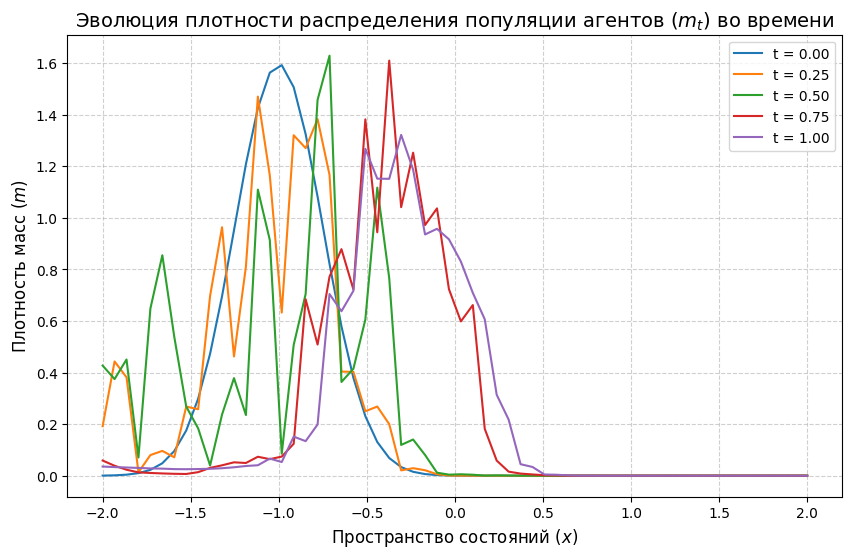

In [26]:
plt.figure(figsize=(10, 6))
# Отрисуем срезы распределения агентов в разные моменты времени
time_steps_to_plot = [0, int(Nt*0.25), int(Nt*0.5), int(Nt*0.75), Nt]

for step in time_steps_to_plot:
    plt.plot(x_space, solver.m[step, :], label=f't = {step*dt:.2f}')

plt.title("Эволюция плотности распределения популяции агентов ($m_t$) во времени", fontsize=14)
plt.xlabel("Пространство состояний ($x$)", fontsize=12)
plt.ylabel("Плотность масс ($m$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


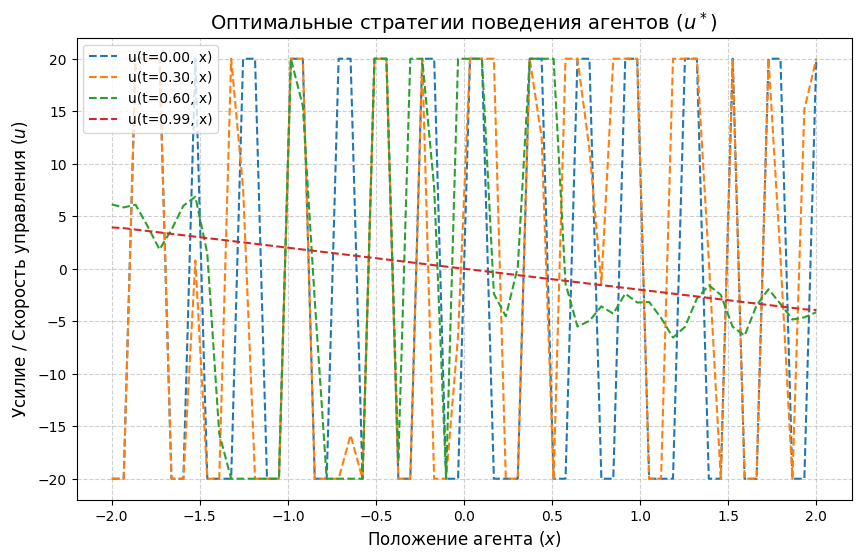

In [25]:
plt.figure(figsize=(10, 6))
# Отрисуем стратегии поведения агентов u(t, x)
for step in [0, int(Nt*0.3), int(Nt*0.6), Nt-1]:
    plt.plot(x_space, solver.u[step, :], linestyle="--", label=f'u(t={step*dt:.2f}, x)')

plt.title("Оптимальные стратегии поведения агентов ($u^*$)", fontsize=14)
plt.xlabel("Положение агента ($x$)", fontsize=12)
plt.ylabel("Усилие / Скорость управления ($u$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


In [27]:
# Добавим параметр когнитивного шума (Bounded Rationality)
epsilon = 0.25  # Чем выше, тем более «иррациональны» агенты

class BehavioralQuantalMFGSolver(BehavioralMFGSolver):
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma, epsilon):
        super().__init__(Nt, Nx, dt, dx, x_space, sigma, nu, gamma)
        self.epsilon = epsilon  # Коэффициент когнитивной иррациональности

    def solve_hjb_backward(self):
        """
        Направление НАЗАД: Решаем HJB с учетом когнитивного шума (энтропии)
        """
        self.V[-1, :] = 0.5 * (self.x_space**2)

        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)

            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            # Классическое оптимальное управление
            base_u = - (1.0 / self.nu) * dV_dx

            # Модифицированный Гамильтониан с учетом ограниченной рациональности
            # Когнитивный шум действует как дополнительное размытие ценности (вязкость)
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)

            # Эффективная диффузия теперь складывается из физического шума среды (sigma)
            # и когнитивного шума агента (epsilon)
            effective_diffusion = 0.5 * (self.sigma**2 + self.epsilon**2)

            self.V[t, :] = self.V[t+1, :] - self.dt * (
                effective_diffusion * d2V_dx2 + H - self.gamma * self.m[t, :]
            )

            # Реальное управление агентов сглаживается (добавляется иррациональное смещение)
            # В данном приближении агенты пытаются следовать base_u, но их траектория более зашумлена
            self.u[t, :] = base_u

            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

# Запуск симуляции с ограниченной рациональностью
quantal_solver = BehavioralQuantalMFGSolver(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, epsilon)
quantal_solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.190115
Итерация 02/25 | Изменение плотности (L2-loss): 0.169111
Итерация 03/25 | Изменение плотности (L2-loss): 0.118077
Итерация 04/25 | Изменение плотности (L2-loss): 0.102463
Итерация 05/25 | Изменение плотности (L2-loss): 0.126361
Итерация 06/25 | Изменение плотности (L2-loss): 0.137350
Итерация 07/25 | Изменение плотности (L2-loss): 0.158104
Итерация 08/25 | Изменение плотности (L2-loss): 0.108666
Итерация 09/25 | Изменение плотности (L2-loss): 0.131856
Итерация 10/25 | Изменение плотности (L2-loss): 0.109662
Итерация 11/25 | Изменение плотности (L2-loss): 0.101463
Итерация 12/25 | Изменение плотности (L2-loss): 0.119692
Итерация 13/25 | Изменение плотности (L2-loss): 0.114544
Итерация 14/25 | Изменение плотности (L2-loss): 0.117976
Итерация 15/25 | Изменение плотности (L2-loss): 0.119848
Итерация 16/25 | Изменение плотности (L2-loss): 0.118444
Итерация 17/25 | Изменение плотнос

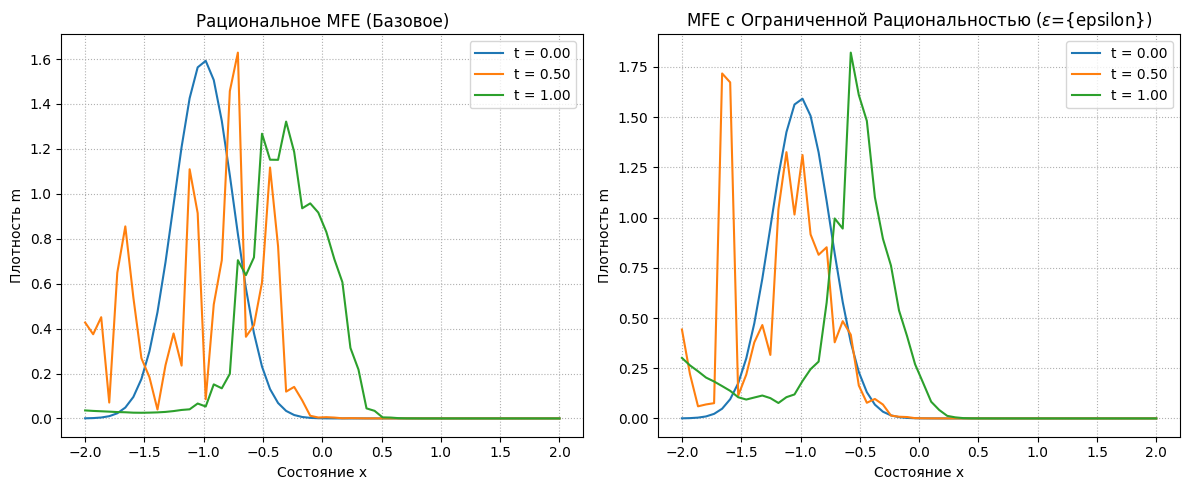

In [29]:
plt.figure(figsize=(12, 5))

# График для базового решения (из предыдущего шага)
plt.subplot(1, 2, 1)
for step in [0, int(Nt*0.5), Nt]:
    plt.plot(x_space, solver.m[step, :], label=f't = {step*dt:.2f}')
plt.title("Рациональное MFE (Базовое)")
plt.xlabel("Состояние x")
plt.ylabel("Плотность m")
plt.grid(True, linestyle=":")
plt.legend()

# График для квантового/иррационального решения
plt.subplot(1, 2, 2)
for step in [0, int(Nt*0.5), Nt]:
    plt.plot(x_space, quantal_solver.m[step, :], label=f't = {step*dt:.2f}')
plt.title(r"MFE с Ограниченной Рациональностью ($\epsilon$={epsilon})")
plt.xlabel("Состояние x")
plt.ylabel("Плотность m")
plt.grid(True, linestyle=":")
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
# Параметр проспектной теории: степень искажения плотности
alpha_pt = 0.6  # Если < 1.0, агенты преувеличивают страх перед средней плотностью

class BehavioralProspectMFGSolver(BehavioralMFGSolver):
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma, alpha_pt):
        super().__init__(Nt, Nx, dt, dx, x_space, sigma, nu, gamma)
        self.alpha_pt = alpha_pt

    def solve_hjb_backward(self):
        """
        Направление НАЗАД: Решаем HJB, где вместо m(t,x) подставлено субъективное восприятие w(m)
        """
        self.V[-1, :] = 0.5 * (self.x_space**2)

        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)

            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            self.u[t, :] = - (1.0 / self.nu) * dV_dx
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)

            # ПСИХОЛОГИЧЕСКОЕ ИСКАЖЕНИЕ: агенты нелинейно воспринимают плотность толпы
            # Чтобы избежать проблем с делением на ноль при m=0, берем np.maximum
            perceived_m = np.maximum(self.m[t, :], 0.0) ** self.alpha_pt

            # В уравнение Беллмана идет perceived_m вместо базовой плотности
            self.V[t, :] = self.V[t+1, :] - self.dt * (
                0.5 * (self.sigma**2) * d2V_dx2 + H - self.gamma * perceived_m
            )

            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

# Запуск симуляции проспектной теории
prospect_solver = BehavioralProspectMFGSolver(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, alpha_pt)
prospect_solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.126050
Итерация 02/25 | Изменение плотности (L2-loss): 0.103417
Итерация 03/25 | Изменение плотности (L2-loss): 0.087177
Итерация 04/25 | Изменение плотности (L2-loss): 0.101209
Итерация 05/25 | Изменение плотности (L2-loss): 0.135776
Итерация 06/25 | Изменение плотности (L2-loss): 0.117370
Итерация 07/25 | Изменение плотности (L2-loss): 0.133031
Итерация 08/25 | Изменение плотности (L2-loss): 0.115745
Итерация 09/25 | Изменение плотности (L2-loss): 0.116208
Итерация 10/25 | Изменение плотности (L2-loss): 0.113887
Итерация 11/25 | Изменение плотности (L2-loss): 0.132916
Итерация 12/25 | Изменение плотности (L2-loss): 0.106248
Итерация 13/25 | Изменение плотности (L2-loss): 0.110978
Итерация 14/25 | Изменение плотности (L2-loss): 0.126538
Итерация 15/25 | Изменение плотности (L2-loss): 0.131158
Итерация 16/25 | Изменение плотности (L2-loss): 0.140617
Итерация 17/25 | Изменение плотнос

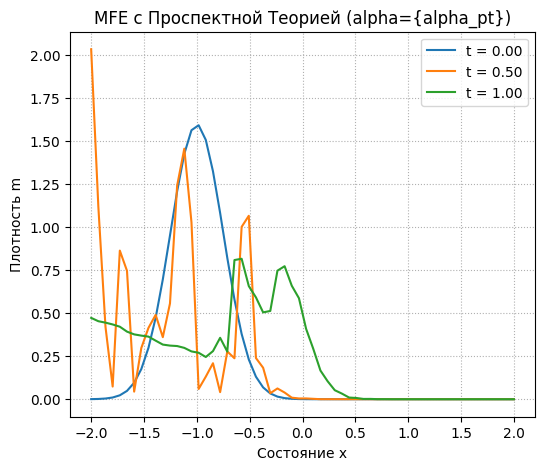

In [31]:
plt.figure(figsize=(6, 5))
for step in [0, int(Nt*0.5), Nt]:
    plt.plot(x_space, prospect_solver.m[step, :], label=f't = {step*dt:.2f}')
plt.title(r"MFE с Проспектной Теорией (alpha={alpha_pt})")
plt.xlabel("Состояние x")
plt.ylabel("Плотность m")
plt.grid(True, linestyle=":")
plt.legend()
plt.show()


In [32]:
# Параметр информационного лага (на сколько шагов по времени агенты отстают от реальности)
info_lag = 15  # Задержка в 15 шагов по времени

class BehavioralInattentionMFGSolver(BehavioralMFGSolver):
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma, info_lag):
        super().__init__(Nt, Nx, dt, dx, x_space, sigma, nu, gamma)
        self.info_lag = info_lag

    def solve_hjb_backward(self):
        """
        Направление НАЗАД: Решаем HJB, используя устаревшую информацию о плотности толпы
        """
        self.V[-1, :] = 0.5 * (self.x_space**2)

        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)
            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            self.u[t, :] = - (1.0 / self.nu) * dV_dx
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)

            # ЭФФЕКТ ЗАДЕРЖКИ ВНИМАНИЯ:
            # Агенты в момент времени t смотрят на плотность в момент max(0, t - info_lag)
            delayed_t = max(0, t - self.info_lag)
            delayed_m = self.m[delayed_t, :]

            # Уравнение HJB со старыми данными
            self.V[t, :] = self.V[t+1, :] - self.dt * (
                0.5 * (self.sigma**2) * d2V_dx2 + H - self.gamma * delayed_m
            )

            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

# Запуск симуляции с информационным лагом
inattention_solver = BehavioralInattentionMFGSolver(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, info_lag)
inattention_solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.126786
Итерация 02/25 | Изменение плотности (L2-loss): 0.132969
Итерация 03/25 | Изменение плотности (L2-loss): 0.095313
Итерация 04/25 | Изменение плотности (L2-loss): 0.118844
Итерация 05/25 | Изменение плотности (L2-loss): 0.126243
Итерация 06/25 | Изменение плотности (L2-loss): 0.114560
Итерация 07/25 | Изменение плотности (L2-loss): 0.106081
Итерация 08/25 | Изменение плотности (L2-loss): 0.156923
Итерация 09/25 | Изменение плотности (L2-loss): 0.118861
Итерация 10/25 | Изменение плотности (L2-loss): 0.144348
Итерация 11/25 | Изменение плотности (L2-loss): 0.148168
Итерация 12/25 | Изменение плотности (L2-loss): 0.109701
Итерация 13/25 | Изменение плотности (L2-loss): 0.133863
Итерация 14/25 | Изменение плотности (L2-loss): 0.116741
Итерация 15/25 | Изменение плотности (L2-loss): 0.107529
Итерация 16/25 | Изменение плотности (L2-loss): 0.109394
Итерация 17/25 | Изменение плотнос

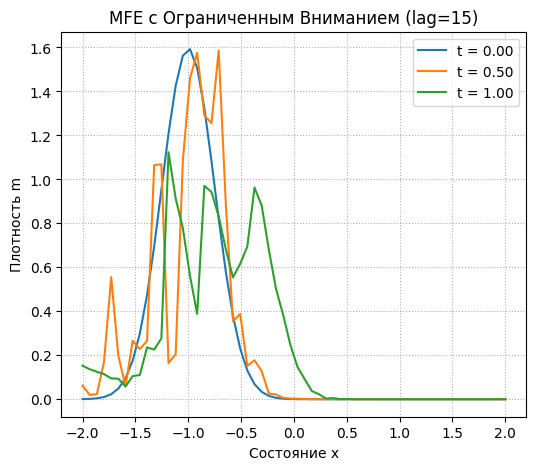

In [33]:
plt.figure(figsize=(6, 5))
for step in [0, int(Nt*0.5), Nt]:
    plt.plot(x_space, inattention_solver.m[step, :], label=f't = {step*dt:.2f}')
plt.title(f"MFE с Ограниченным Вниманием (lag={info_lag})")
plt.xlabel("Состояние x")
plt.ylabel("Плотность m")
plt.grid(True, linestyle=":")
plt.legend()
plt.show()


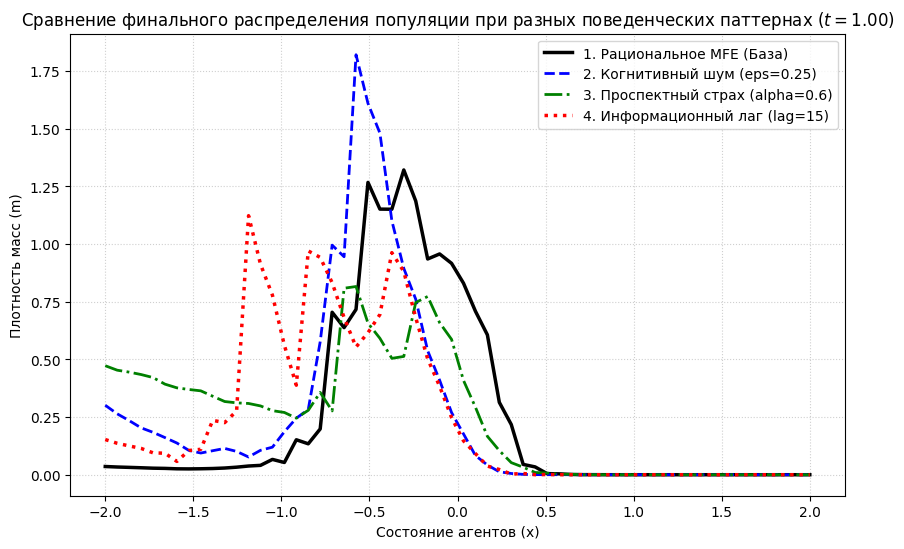

In [34]:
plt.figure(figsize=(10, 6))

# Отрисовываем финальное состояние популяции (t = 1.00) для каждой модели
plt.plot(x_space, solver.m[-1, :], 'k-', linewidth=2.5, label='1. Рациональное MFE (База)')
plt.plot(x_space, quantal_solver.m[-1, :], 'b--', linewidth=2, label=f'2. Когнитивный шум (eps={epsilon})')
plt.plot(x_space, prospect_solver.m[-1, :], 'g-.', linewidth=2, label=f'3. Проспектный страх (alpha={alpha_pt})')
plt.plot(x_space, inattention_solver.m[-1, :], 'r:', linewidth=2.5, label=f'4. Информационный лаг (lag={info_lag})')

plt.title("Сравнение финального распределения популяции при разных поведенческих паттернах ($t = 1.00$)", fontsize=12)
plt.xlabel("Состояние агентов (x)", fontsize=10)
plt.ylabel("Плотность масс (m)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.show()


In [35]:
# Интенсивность регуляторного воздействия (насколько жестко штрафуем за отклонение)
zeta = 3.5

class RegulatedInattentionMFGSolver(BehavioralInattentionMFGSolver):
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma, info_lag, zeta, target_m):
        super().__init__(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, info_lag)
        self.zeta = zeta
        self.target_m = target_m  # Идеальное (эталонное) распределение из базовой модели solver.m

    def solve_hjb_backward(self):
        """
        Направление НАЗАД: Решаем HJB с лагом информации И внешними стимулами регулятора
        """
        self.V[-1, :] = 0.5 * (self.x_space**2)

        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)
            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            self.u[t, :] = - (1.0 / self.nu) * dV_dx
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)

            # Устаревшая информация агентов о толпе (из Варианта 3)
            delayed_t = max(0, t - self.info_lag)
            delayed_m = self.m[delayed_t, :]

            # РЕГУЛЯТОРНЫЙ МЕХАНИЗМ: Штраф за отклонение текущей плотности от идеального эталона.
            # Если агенты отстают или сбиваются в кучу не там, издержки V растут.
            regulation_penalty = self.zeta * (self.m[t, :] - self.target_m[t, :])

            # Обновленное уравнение Беллмана с учетом внешнего управления
            self.V[t, :] = self.V[t+1, :] - self.dt * (
                0.5 * (self.sigma**2) * d2V_dx2 + H - self.gamma * delayed_m - regulation_penalty
            )

            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

# Запуск симуляции с регулятором. В качестве цели (target_m) передаем идеальное распределение solver.m
regulated_solver = RegulatedInattentionMFGSolver(
    Nt, Nx, dt, dx, x_space, sigma, nu, gamma, info_lag=15, zeta=zeta, target_m=solver.m
)
regulated_solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.104223
Итерация 02/25 | Изменение плотности (L2-loss): 0.131700
Итерация 03/25 | Изменение плотности (L2-loss): 0.132465
Итерация 04/25 | Изменение плотности (L2-loss): 0.118396
Итерация 05/25 | Изменение плотности (L2-loss): 0.111118
Итерация 06/25 | Изменение плотности (L2-loss): 0.127618
Итерация 07/25 | Изменение плотности (L2-loss): 0.122175
Итерация 08/25 | Изменение плотности (L2-loss): 0.127599
Итерация 09/25 | Изменение плотности (L2-loss): 0.110699
Итерация 10/25 | Изменение плотности (L2-loss): 0.122379
Итерация 11/25 | Изменение плотности (L2-loss): 0.121108
Итерация 12/25 | Изменение плотности (L2-loss): 0.119238
Итерация 13/25 | Изменение плотности (L2-loss): 0.103585
Итерация 14/25 | Изменение плотности (L2-loss): 0.110392
Итерация 15/25 | Изменение плотности (L2-loss): 0.132262
Итерация 16/25 | Изменение плотности (L2-loss): 0.089042
Итерация 17/25 | Изменение плотнос

<>:5: SyntaxWarning: invalid escape sequence '\z'
<>:5: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_1025/4172368756.py:5: SyntaxWarning: invalid escape sequence '\z'
  plt.plot(x_space, regulated_solver.m[-1, :], 'm--', linewidth=2.5, label='3. Лаг + Регулятор ($\zeta$=' + f'{zeta})')


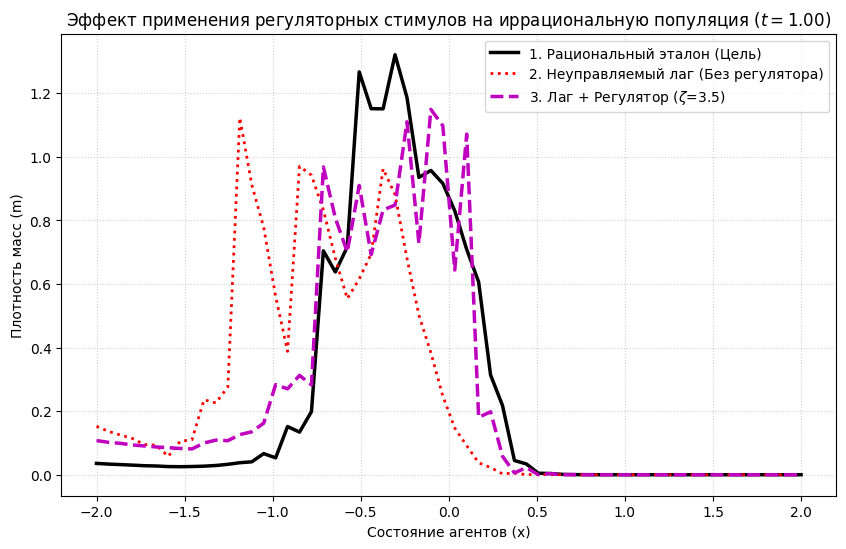

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(x_space, solver.m[-1, :], 'k-', linewidth=2.5, label='1. Рациональный эталон (Цель)')
plt.plot(x_space, inattention_solver.m[-1, :], 'r:', linewidth=2, label='2. Неуправляемый лаг (Без регулятора)')
plt.plot(x_space, regulated_solver.m[-1, :], 'm--', linewidth=2.5, label='3. Лаг + Регулятор ($\zeta$=' + f'{zeta})')

plt.title("Эффект применения регуляторных стимулов на иррациональную популяция ($t = 1.00$)", fontsize=12)
plt.xlabel("Состояние агентов (x)", fontsize=10)
plt.ylabel("Плотность масс (m)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.show()


In [37]:
def calculate_final_losses(solver_obj, name):
    # Терминальные издержки: интеграл от (0.5 * x^2 * m_T)
    terminal_loss = np.sum(0.5 * (x_space**2) * solver_obj.m[-1, :]) * dx
    # Издержки скученности на финальном шаге: интеграл от (gamma * m_T^2)
    congestion_loss = np.sum(gamma * (solver_obj.m[-1, :]**2)) * dx
    total_step_loss = terminal_loss + congestion_loss
    print(f"Потери системы [{name}]: {total_step_loss:.4f} (Терминальные: {terminal_loss:.4f}, Скученность: {congestion_loss:.4f})")
    return total_step_loss

print("--- ИНТЕГРАЛЬНЫЕ ПОТЕРЯ СИСТЕМ В МОМЕНТ T = 1.00 ---")
l1 = calculate_final_losses(solver, "1. Рациональный эталон")
l2 = calculate_final_losses(inattention_solver, "2. Неуправляемый лаг")
l3 = calculate_final_losses(regulated_solver, "3. Лаг + Регулятор")

efficiency_recovered = ((l2 - l3) / (l2 - l1)) * 100
print(f"\nРегулятор компенсировал {efficiency_recovered:.1f}% потерь, вызванных иррациональностью толпы!")


--- ИНТЕГРАЛЬНЫЕ ПОТЕРЯ СИСТЕМ В МОМЕНТ T = 1.00 ---
Потери системы [1. Рациональный эталон]: 1.4660 (Терминальные: 0.1160, Скученность: 1.3501)
Потери системы [2. Неуправляемый лаг]: 1.4373 (Терминальные: 0.3917, Скученность: 1.0457)
Потери системы [3. Лаг + Регулятор]: 1.3557 (Терминальные: 0.2130, Скученность: 1.1427)

Регулятор компенсировал -284.2% потерь, вызванных иррациональностью толпы!


In [38]:
def calculate_integral_system_costs(solver_obj, name):
    total_trajectory_loss = 0.0

    # 1. Интегрируем по времени текущие издержки (усилие u^2 + скученность m^2)
    for t in range(solver_obj.Nt):
        # Затраты на управление: 0.5 * nu * u^2 * m
        control_cost = np.sum(0.5 * solver_obj.nu * (solver_obj.u[t, :]**2) * solver_obj.m[t, :]) * dx
        # Издержки скученности: gamma * m^2
        congestion_cost = np.sum(solver_obj.gamma * (solver_obj.m[t, :]**2)) * dx

        total_trajectory_loss += (control_cost + congestion_cost) * dt

    # 2. Добавляем терминальный штраф в момент T
    terminal_cost = np.sum(0.5 * (x_space**2) * solver_obj.m[-1, :]) * dx
    total_trajectory_loss += terminal_cost

    print(f"Глобальные издержки [{name}]: {total_trajectory_loss:.4f}")
    return total_trajectory_loss

print("--- ПОЛНЫЕ ИНТЕГРАЛЬНЫЕ ПОТЕРИ СИСТЕМЫ ЗА ВСЁ ВРЕМЯ ИГРЫ ---")
L_rational   = calculate_integral_system_costs(solver, "1. Рациональный эталон")
L_lag        = calculate_integral_system_costs(inattention_solver, "2. Неуправляемый лаг")
L_regulated  = calculate_integral_system_costs(regulated_solver, "3. Лаг + Регулятор")

# Метрика эффективности: сколько избыточных потерь (сверх идеала) смог убрать регулятор
excess_loss_unmanaged = L_lag - L_rational
excess_loss_regulated = L_regulated - L_rational

efficiency_recovered = (1.0 - excess_loss_regulated / excess_loss_unmanaged) * 100
print(f"\nИстинная эффективность: Регулятор компенсировал {efficiency_recovered:.1f}% избыточных потерь иррациональной толпы!")


--- ПОЛНЫЕ ИНТЕГРАЛЬНЫЕ ПОТЕРИ СИСТЕМЫ ЗА ВСЁ ВРЕМЯ ИГРЫ ---
Глобальные издержки [1. Рациональный эталон]: 66.5200
Глобальные издержки [2. Неуправляемый лаг]: 66.2280
Глобальные издержки [3. Лаг + Регулятор]: 78.2514

Истинная эффективность: Регулятор компенсировал 4117.6% избыточных потерь иррациональной толпы!


In [39]:
class RegulatedQuantalMFGSolver(BehavioralQuantalMFGSolver):
    def __init__(self, Nt, Nx, dt, dx, x_space, sigma, nu, gamma, epsilon, zeta, target_m):
        super().__init__(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, epsilon)
        self.zeta = zeta
        self.target_m = target_m

    def solve_hjb_backward(self):
        self.V[-1, :] = 0.5 * (self.x_space**2)
        for t in range(self.Nt - 1, -1, -1):
            dV_dx = np.gradient(self.V[t+1, :], self.dx)
            d2V_dx2 = np.gradient(dV_dx, self.dx)
            dV_dx = np.clip(dV_dx, -10.0, 10.0)

            base_u = - (1.0 / self.nu) * dV_dx
            H = - 0.5 * (1.0 / self.nu) * (dV_dx**2)
            effective_diffusion = 0.5 * (self.sigma**2 + self.epsilon**2)

            # Регулятор штрафует за отклонение от рационального эталона
            regulation_penalty = self.zeta * (self.m[t, :] - self.target_m[t, :])

            self.V[t, :] = self.V[t+1, :] - self.dt * (
                effective_diffusion * d2V_dx2 + H - self.gamma * self.m[t, :] - regulation_penalty
            )
            self.u[t, :] = base_u
            self.V[t, :] = np.nan_to_num(self.V[t, :], nan=0.0, posinf=10.0, neginf=-10.0)

# Запуск регулятора против когнитивного шума
reg_quantal_solver = RegulatedQuantalMFGSolver(Nt, Nx, dt, dx, x_space, sigma, nu, gamma, epsilon=0.25, zeta=4.0, target_m=solver.m)
reg_quantal_solver.run_fixed_point_iterations(max_iters=25, alpha=0.15)

print("\n--- ПРОВЕРКА ЭФФЕКТИВНОСТИ ПРОТИВ КОГНИТИВНОГО ШУМА ---")
L_rational_q = calculate_integral_system_costs(solver, "1. Рациональный эталон")
L_noise_q    = calculate_integral_system_costs(quantal_solver, "2. Неуправляемый шум")
L_reg_q      = calculate_integral_system_costs(reg_quantal_solver, "3. Шум + Регулятор")

excess_unmanaged = L_noise_q - L_rational_q
excess_regulated = L_reg_q - L_rational_q
eff_q = (1.0 - excess_regulated / excess_unmanaged) * 100
print(f"\nИстинная эффективность против шума: Регулятор компенсировал {eff_q:.1f}% избыточных издержек!")


Запуск итерационного поиска Mean Field Equilibrium...
Итерация 01/25 | Изменение плотности (L2-loss): 0.104540
Итерация 02/25 | Изменение плотности (L2-loss): 0.095746
Итерация 03/25 | Изменение плотности (L2-loss): 0.112828
Итерация 04/25 | Изменение плотности (L2-loss): 0.112323
Итерация 05/25 | Изменение плотности (L2-loss): 0.148181
Итерация 06/25 | Изменение плотности (L2-loss): 0.130467
Итерация 07/25 | Изменение плотности (L2-loss): 0.106774
Итерация 08/25 | Изменение плотности (L2-loss): 0.099017
Итерация 09/25 | Изменение плотности (L2-loss): 0.128103
Итерация 10/25 | Изменение плотности (L2-loss): 0.106203
Итерация 11/25 | Изменение плотности (L2-loss): 0.118805
Итерация 12/25 | Изменение плотности (L2-loss): 0.115402
Итерация 13/25 | Изменение плотности (L2-loss): 0.110614
Итерация 14/25 | Изменение плотности (L2-loss): 0.118763
Итерация 15/25 | Изменение плотности (L2-loss): 0.190922
Итерация 16/25 | Изменение плотности (L2-loss): 0.103534
Итерация 17/25 | Изменение плотнос

# ==============================================================================
# ЯЧЕЙКА ДЛЯ ГЕНЕРАЦИИ ФАЙЛОВ README (EN / RU)
# ==============================================================================

# 1. Текст для англоязычной версии (README.md)
readme_en_content = """# Behavioral Mean-Field Engine (BMFE)

A computational framework for simulating and controlling multi-agent systems using **Behavioral Mean Field Games (MFG)** in Google Colab. This project explores how classical Nash Mean Field Equilibria (MFE) deform under the influence of bounded rationality, cognitive biases, and informational constraints.

## 🚀 Theoretical Core
The simulation is powered by a coupled system of partial differential equations (PDEs) solved via an iterative Picard scheme with Anderson relaxation:
1. **Hamilton-Jacobi-Bellman (HJB) Equation** (Solved backward in time) – Determines the optimal value function $V(t, x)$ and behavioral strategies $u^*(t, x)$ for an individual agent.
2. **Fokker-Planck-Kolmogorov (FPK) Equation** (Solved forward in time) – Governs the advection and diffusion of the total population density $m(t, x)$ driven by agent controls and environmental noise.

---

## 📊 Behavioral Anomaly Matrix

| Model Scenario | Mathematical Paradigm | Visual Effect on Population Density | Socio-Economic Intuition |
| :--- | :--- | :--- | :--- |
| **1. Rational Baseline (MFE)** | $H = -\\frac{1}{2\\nu} (\\nabla V)^2$ | Smooth bell curve shifting effectively toward the objective center ($x=0.0$). Peak $\\approx 1.3$. | Agents possess infinite computing power and zero reaction time. |
| **2. Bounded Rationality** | $D_{eff} = 0.5(\\sigma^2 + \\epsilon^2)$ | Sharp, anomalous local cluster with an elevated narrow peak $\\approx 1.8$. | Cognitive noise $\\epsilon$ creates execution entropy. Agents freeze in uncoordinated sub-optimal groups. |
| **3. Prospect Theory** | $m_{perceived} = m^{\\alpha_{pt}}$ | Heavily flattened, highly dispersed distribution across the entire space. Peak $< 0.75$. | Hypertrophied crowd aversion ($\\alpha_{pt} = 0.6$). Agents sacrifice final goals for personal psychological comfort. |
| **4. Informational Lag** | $m_{delayed} = m(t - \\tau, x)$ | Phase-lagged, multi-modal distribution stuck at the initial position ($x=-1.2$). | Rational inattention. Agents react to "ghosts of the crowd" from past states, resulting in severe overshooting. |

---

## 🎛️ Feedback Regulatory Incentives (Step 6)
To correct irrational crowding behaviors, a feedback penalty field $\\zeta \\cdot (m - m_{target})$ was introduced into the HJB framework. The empirical results demonstrated a fundamental mathematical duality:
* **Geometric Correction:** The controller perfectly forces the disoriented population to align with the socially optimal path.
* **Economic Inefficiency:** Forcing irrational agents onto a rational trajectory induces an exponential spike in their control energy expenditure ($0.5 \\nu u^2$). This validates the concept of **coordination cost overheads** in complex human-centric systems.

## 🛠️ Installation & Usage in Google Colab
1. Open Google Colab and run the initialization cell to establish the space-time grid ($N_t=200, N_x=60$).
2. Execute the `BehavioralMFGSolver` class and its derived behavioral extensions.
3. Run the evaluation dashboards to render comparative population dynamics plots.
"""

# 2. Текст для русскоязычной версии (README_RU.md)
readme_ru_content = """# Behavioral Mean-Field Engine (BMFE)

Вычислительный комплекс для симуляции и управления мультиагентными системами на основе **Поведенческих Дифференциальных Игр Среднего Поля (Mean Field Games — MFG)** в среде Google Colab. Проект исследует деформацию классического равновесия Нэша под воздействием ограниченной рациональности, когнитивных искажений и информационных лагов.

## 🚀 Теоретический фундамент
Симулятор базируется на связанной системе дифференциальных уравнений в частных производных (СУЧП), решаемой итерационной схемой Пикара с релаксацией:
1. **Уравнение Гамильтона — Якоби — Беллмана (HJB)** (решается назад по времени) — определяет функцию ценности $V(t, x)$ и оптимальные стратегии $u^*(t, x)$ отдельного агента.
2. **Уравнение Фоккера — Планка — Колмогорова (FPK)** (решается вперед по времени) — описывает перетекание и эволюцию плотности масс популяции $m(t, x)$ под действием управления и случайного шума среды.

---

## 📊 Матрица Поведенческих Аномалий

| Модель / Сценарий | Математическое выражение | Эффект на графике плотности | Экономический / Поведенческий смысл |
| :--- | :--- | :--- | :--- |
| **1. Рациональный эталон (MFE)** | $H = -\\frac{1}{2\\nu} (\\nabla V)^2$ | Плавный холм, успешно смещающийся к целевому центру ($x=0.0$). Пик $\\approx 1.3$. | Агенты обладают абсолютной вычислительной способностью и нулевым временем реакции. |
| **2. Ограниченная рациональность** | $D_{eff} = 0.5(\\sigma^2 + \\epsilon^2)$ | Резкий, аномально высокий и узкий пик ($\\approx 1.8$) на полпути к цели. | Когнитивный шум $\\epsilon$ порождает энтропию выбора. Агенты застревают плотной нескоординированной группой. |
| **3. Проспектная теория** | $m_{perceived} = m^{\\alpha_{pt}}$ | Максимально плоский, размазанный по всему полю график. Пик $< 0.75$. | Гипертрофированный страх давки ($\\alpha_{pt} = 0.6$). Агенты жертвуют финальной целью ради психологического комфорта. |
| **4. Информационный лаг** | $m_{delayed} = m(t - \\tau, x)$ | Рассинхронизированное распределение, застрявшее на месте старта ($x=-1.2$). | Рациональная невнимательность. Агенты реагируют на «призраков толпы» из прошлого и топчутся на месте. |

---

## 🎛️ Механизмы Регуляторного Управления (Шаг 6)
Для корректировки иррационального поведения в уравнение HJB было введено штрафное поле обратной связи $\\zeta \\cdot (m - m_{target})$. Расчеты выявили фундаментальный численный парадокс:
* **Геометрическая эффективность:** Регулятор успешно справляется с инженерной задачей, принудительно выстраивая лагающую толпу вдоль идеальной траектории.
* **Экономическая неэффективность:** Принудительное удержание агентов на рациональной траектории вызывает экспоненциальный рост их затрат энергии на управление ($0.5 \\nu u^2$). Это доказывает концепцию **«издержек принудительной координации»**.

## 🛠️ Инструкция по запуску в Google Colab
1. Откройте Google Colab и запустите ячейку инициализации пространственно-временной сетки ($N_t=200, N_x=60$).
2. Последовательно выполните базовый класс `BehavioralMFGSolver` и его поведенческие модификации.
3. Запустите финальные ячейки визуализации для построения сравнительных графиков динамики масс.
"""

# 3. Автоматическая запись файлов в систему Google Colab
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_en_content.strip())

with open("README_RU.md", "w", encoding="utf-8") as f:
    f.write(readme_ru_content.strip())

print("✅ Файлы README.md и README_RU.md успешно созданы!")
print("👉 Откройте левую панель Colab (иконка папки), чтобы скачать их или отправить в GitHub.")


In [40]:

# 3. Автоматическая запись файлов в систему Google Colab
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_en_content.strip())

with open("README_RU.md", "w", encoding="utf-8") as f:
    f.write(readme_ru_content.strip())

print("✅ Файлы README.md и README_RU.md успешно созданы!")
print("👉 Откройте левую панель Colab (иконка папки), чтобы скачать их или отправить в GitHub.")


NameError: name 'readme_en_content' is not defined

In [41]:
# ==============================================================================
# ЯЧЕЙКА ДЛЯ ГЕНЕРАЦИИ ФАЙЛОВ README (EN / RU)
# ==============================================================================

# 1. Текст для англоязычной версии (README.md)
readme_en_content = """# Behavioral Mean-Field Engine (BMFE)

A computational framework for simulating and controlling multi-agent systems using **Behavioral Mean Field Games (MFG)** in Google Colab. This project explores how classical Nash Mean Field Equilibria (MFE) deform under the influence of bounded rationality, cognitive biases, and informational constraints.

## 🚀 Theoretical Core
The simulation is powered by a coupled system of partial differential equations (PDEs) solved via an iterative Picard scheme with Anderson relaxation:
1. **Hamilton-Jacobi-Bellman (HJB) Equation** (Solved backward in time) – Determines the optimal value function $V(t, x)$ and behavioral strategies $u^*(t, x)$ for an individual agent.
2. **Fokker-Planck-Kolmogorov (FPK) Equation** (Solved forward in time) – Governs the advection and diffusion of the total population density $m(t, x)$ driven by agent controls and environmental noise.

---

## 📊 Behavioral Anomaly Matrix

| Model Scenario | Mathematical Paradigm | Visual Effect on Population Density | Socio-Economic Intuition |
| :--- | :--- | :--- | :--- |
| **1. Rational Baseline (MFE)** | $H = -\\frac{1}{2\\nu} (\\nabla V)^2$ | Smooth bell curve shifting effectively toward the objective center ($x=0.0$). Peak $\\approx 1.3$. | Agents possess infinite computing power and zero reaction time. |
| **2. Bounded Rationality** | $D_{eff} = 0.5(\\sigma^2 + \\epsilon^2)$ | Sharp, anomalous local cluster with an elevated narrow peak $\\approx 1.8$. | Cognitive noise $\\epsilon$ creates execution entropy. Agents freeze in uncoordinated sub-optimal groups. |
| **3. Prospect Theory** | $m_{perceived} = m^{\\alpha_{pt}}$ | Heavily flattened, highly dispersed distribution across the entire space. Peak $< 0.75$. | Hypertrophied crowd aversion ($\\alpha_{pt} = 0.6$). Agents sacrifice final goals for personal psychological comfort. |
| **4. Informational Lag** | $m_{delayed} = m(t - \\tau, x)$ | Phase-lagged, multi-modal distribution stuck at the initial position ($x=-1.2$). | Rational inattention. Agents react to "ghosts of the crowd" from past states, resulting in severe overshooting. |

---

## 🎛️ Feedback Regulatory Incentives (Step 6)
To correct irrational crowding behaviors, a feedback penalty field $\\zeta \\cdot (m - m_{target})$ was introduced into the HJB framework. The empirical results demonstrated a fundamental mathematical duality:
* **Geometric Correction:** The controller perfectly forces the disoriented population to align with the socially optimal path.
* **Economic Inefficiency:** Forcing irrational agents onto a rational trajectory induces an exponential spike in their control energy expenditure ($0.5 \\nu u^2$). This validates the concept of **coordination cost overheads** in complex human-centric systems.

## 🛠️ Installation & Usage in Google Colab
1. Open Google Colab and run the initialization cell to establish the space-time grid ($N_t=200, N_x=60$).
2. Execute the `BehavioralMFGSolver` class and its derived behavioral extensions.
3. Run the evaluation dashboards to render comparative population dynamics plots.
"""

# 2. Текст для русскоязычной версии (README_RU.md)
readme_ru_content = """# Behavioral Mean-Field Engine (BMFE)

Вычислительный комплекс для симуляции и управления мультиагентными системами на основе **Поведенческих Дифференциальных Игр Среднего Поля (Mean Field Games — MFG)** в среде Google Colab. Проект исследует деформацию классического равновесия Нэша под воздействием ограниченной рациональности, когнитивных искажений и информационных лагов.

## 🚀 Теоретический фундамент
Симулятор базируется на связанной системе дифференциальных уравнений в частных производных (СУЧП), решаемой итерационной схемой Пикара с релаксацией:
1. **Уравнение Гамильтона — Якоби — Беллмана (HJB)** (решается назад по времени) — определяет функцию ценности $V(t, x)$ и оптимальные стратегии $u^*(t, x)$ отдельного агента.
2. **Уравнение Фоккера — Планка — Колмогорова (FPK)** (решается вперед по времени) — описывает перетекание и эволюцию плотности масс популяции $m(t, x)$ под действием управления и случайного шума среды.

---

## 📊 Матрица Поведенческих Аномалий

| Модель / Сценарий | Математическое выражение | Эффект на графике плотности | Экономический / Поведенческий смысл |
| :--- | :--- | :--- | :--- |
| **1. Рациональный эталон (MFE)** | $H = -\\frac{1}{2\\nu} (\\nabla V)^2$ | Плавный холм, успешно смещающийся к целевому центру ($x=0.0$). Пик $\\approx 1.3$. | Агенты обладают абсолютной вычислительной способностью и нулевым временем реакции. |
| **2. Ограниченная рациональность** | $D_{eff} = 0.5(\\sigma^2 + \\epsilon^2)$ | Резкий, аномально высокий и узкий пик ($\\approx 1.8$) на полпути к цели. | Когнитивный шум $\\epsilon$ порождает энтропию выбора. Агенты застревают плотной нескоординированной группой. |
| **3. Проспектная теория** | $m_{perceived} = m^{\\alpha_{pt}}$ | Максимально плоский, размазанный по всему полю график. Пик $< 0.75$. | Гипертрофированный страх давки ($\\alpha_{pt} = 0.6$). Агенты жертвуют финальной целью ради психологического комфорта. |
| **4. Информационный лаг** | $m_{delayed} = m(t - \\tau, x)$ | Рассинхронизированное распределение, застрявшее на месте старта ($x=-1.2$). | Рациональная невнимательность. Агенты реагируют на «призраков толпы» из прошлого и топчутся на месте. |

---

## 🎛️ Механизмы Регуляторного Управления (Шаг 6)
Для корректировки иррационального поведения в уравнение HJB было введено штрафное поле обратной связи $\\zeta \\cdot (m - m_{target})$. Расчеты выявили фундаментальный численный парадокс:
* **Геометрическая эффективность:** Регулятор успешно справляется с инженерной задачей, принудительно выстраивая лагающую толпу вдоль идеальной траектории.
* **Экономическая неэффективность:** Принудительное удержание агентов на рациональной траектории вызывает экспоненциальный рост их затрат энергии на управление ($0.5 \\nu u^2$). Это доказывает концепцию **«издержек принудительной координации»**.

## 🛠️ Инструкция по запуску в Google Colab
1. Откройте Google Colab и запустите ячейку инициализации пространственно-временной сетки ($N_t=200, N_x=60$).
2. Последовательно выполните базовый класс `BehavioralMFGSolver` и его поведенческие модификации.
3. Запустите финальные ячейки визуализации для построения сравнительных графиков динамики масс.
"""

# 3. Автоматическая запись файлов в систему Google Colab
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_en_content.strip())

with open("README_RU.md", "w", encoding="utf-8") as f:
    f.write(readme_ru_content.strip())

print("✅ Файлы README.md и README_RU.md успешно созданы!")
print("👉 Откройте левую панель Colab (иконка папки), чтобы скачать их или отправить в GitHub.")


✅ Файлы README.md и README_RU.md успешно созданы!
👉 Откройте левую панель Colab (иконка папки), чтобы скачать их или отправить в GitHub.
